### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [ ]:
# clone the repo into Colab
!rm -rf ECE_C147A_Final
!GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/DysonLewis/ECE_C147A_Final.git

'''
from google.colab import files
files.upload()
!mv generic.ckpt /content/ECE_C147A_Final/Project/emg2qwerty/models/
'''

Cloning into 'ECE_C147A_Final'...
remote: Enumerating objects: 385, done.
remote: Counting objects: 100% (281/281), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 385 (delta 133), reused 128 (delta 51), pack-reused 104 (from 1)
Receiving objects: 100% (385/385), 34.49 MiB | 24.58 MiB/s, done.
Resolving deltas: 100% (142/142), done.


'\nfrom google.colab import files\nfiles.upload()\n!mv generic.ckpt /content/ECE_C147A_Final/Project/emg2qwerty/models/\n'

### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [4]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty

!mkdir data/

!cp /content/drive/MyDrive/data/* /content/ECE_C147A_Final/Project/emg2qwerty/data/

/content/ECE_C147A_Final/Project/emg2qwerty


In [5]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.6/553.6 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [ ]:
# ─── Step 1: Delete the old files ────────────────────────────────────────────
import os

files_to_delete = [
    "emg2qwerty/modules.py",
    "emg2qwerty/lightning.py",
    "config/base.yaml",
    "config/model/cnn_ctc.yaml",
    "config/model/rnn_ctc.yaml",
    "config/model/cnn_gru_ctc.yaml",
    "config/model/cnn_lstm_ctc.yaml",
    "config/model/cnn_transformer_ctc.yaml",
    "config/model/rnn_gru_ctc.yaml",
    "config/model/rnn_lstm_ctc.yaml",
    "config/model/rnn_transformer_ctc.yaml",
]

for f in files_to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")
    else:
        print(f"Not found (skipping): {f}")

# ─── Step 2: Upload the zip ───────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # upload emg2qwerty_fixes.zip here

# ─── Step 3: Unzip and place files in the correct locations ──────────────────
import zipfile, shutil

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/tmp/fixes")

# Map extracted paths → destination paths
file_map = {
    "/tmp/fixes/emg2qwerty/modules.py":                       "emg2qwerty/modules.py",
    "/tmp/fixes/emg2qwerty/lightning.py":                     "emg2qwerty/lightning.py",
    "/tmp/fixes/config/base.yaml":                            "config/base.yaml",
    "/tmp/fixes/config/model/cnn_ctc.yaml":                   "config/model/cnn_ctc.yaml",
    "/tmp/fixes/config/model/rnn_ctc.yaml":                   "config/model/rnn_ctc.yaml",
    "/tmp/fixes/config/model/cnn_gru_ctc.yaml":               "config/model/cnn_gru_ctc.yaml",
    "/tmp/fixes/config/model/cnn_lstm_ctc.yaml":              "config/model/cnn_lstm_ctc.yaml",
    "/tmp/fixes/config/model/cnn_transformer_ctc.yaml":       "config/model/cnn_transformer_ctc.yaml",
    "/tmp/fixes/config/model/rnn_gru_ctc.yaml":               "config/model/rnn_gru_ctc.yaml",
    "/tmp/fixes/config/model/rnn_lstm_ctc.yaml":              "config/model/rnn_lstm_ctc.yaml",
    "/tmp/fixes/config/model/rnn_transformer_ctc.yaml":       "config/model/rnn_transformer_ctc.yaml",
}

for src, dst in file_map.items():
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)
    print(f"Placed: {dst}")

print("All files replaced. You're good to go.")

Not found (skipping): emg2qwerty/modules.py
Not found (skipping): emg2qwerty/lightning.py
Not found (skipping): config/base.yaml
Not found (skipping): config/model/cnn_ctc.yaml
Not found (skipping): config/model/rnn_ctc.yaml
Not found (skipping): config/model/cnn_gru_ctc.yaml
Not found (skipping): config/model/cnn_lstm_ctc.yaml
Not found (skipping): config/model/cnn_transformer_ctc.yaml
Deleted: config/model/rnn_gru_ctc.yaml
Deleted: config/model/rnn_lstm_ctc.yaml
Not found (skipping): config/model/rnn_transformer_ctc.yaml


Saving emg2qwerty_fixes.zip to emg2qwerty_fixes (1).zip
Placed: emg2qwerty/modules.py
Placed: emg2qwerty/lightning.py
Placed: config/base.yaml
Placed: config/model/cnn_ctc.yaml
Placed: config/model/rnn_ctc.yaml
Placed: config/model/cnn_gru_ctc.yaml
Placed: config/model/cnn_lstm_ctc.yaml
Placed: config/model/cnn_transformer_ctc.yaml
Placed: config/model/rnn_gru_ctc.yaml
Placed: config/model/rnn_lstm_ctc.yaml
Placed: config/model/rnn_transformer_ctc.yaml
All files replaced. You're good to go.


In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
!python -m emg2qwerty.train \
  user="single_user" \
  model=cnn_transformer_ctc \
  transforms=fourier_features \
  dataset.root=data \
  trainer.accelerator=gpu trainer.devices=1 \
  +trainer.max_time="00:00:07:00" \
  batch_size=64 \
  num_workers=8 \
  optimizer.lr=0.0015 \
  +trainer.log_every_n_steps=5
  #--multirun

/content/ECE_C147A_Final/Project/emg2qwerty
[2026-03-09 18:13:45,961][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-

#### Fourier Features Training

The Nyquist verification prints how much signal power would be aliased at each downsample factor.

In [ ]:
from pathlib import Path
import h5py
import numpy as np

data_dir = Path('data')
hdf5_files = list(data_dir.glob('*.hdf5'))

fs = 2000
with h5py.File(hdf5_files[0], 'r') as f:
    emg = f['emg2qwerty']['timeseries']['emg_left'][:10000, 0]

freqs = np.fft.rfftfreq(len(emg), d=1.0 / fs)
psd   = np.abs(np.fft.rfft(emg)) ** 2
total = psd.sum()

semg_pct = 100 * psd[(freqs >= 20) & (freqs <= 500)].sum() / total
print(f'Power in 20-500 Hz sEMG band: {semg_pct:.1f}% of total\n')
print(f'{"Factor":<8} {"Effective fs":<15} {"Aliased power %":<18} {"Status"}')
print('-' * 58)
for factor in [1, 2, 4, 8]:
    eff_fs  = fs // factor
    aliased = 100 * psd[freqs > (eff_fs / 2)].sum() / total
    status  = 'safe' if factor <= 2 else 'violates Nyquist'
    print(f'{factor:<8} {eff_fs:<15} {aliased:<18.2f} {status}')

data_fourier ready: 18 sessions linked
Power in 20-500 Hz sEMG band: 92.7% of total

Factor   Effective fs    Aliased power %    Status
----------------------------------------------------------
1        2000            0.00               safe
2        1000            7.34               safe
4        500             22.82              violates Nyquist
8        250             49.16              violates Nyquist


##TESTING CONFIGS

#CNN

In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
import time, json, threading, subprocess
import psutil
from pathlib import Path

def sample_memory(samples, stop_event, interval=60):
    while not stop_event.is_set():
        ram_gb = psutil.virtual_memory().used / 1e9
        try:
            smi = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                text=True
            )
            vram_mb = int(smi.strip())
        except Exception:
            vram_mb = None
        samples.append({
            "elapsed_min": round((time.time() - samples[0]["t0"]) / 60, 2),
            "ram_gb": round(ram_gb, 2),
            "vram_mb": vram_mb,
            "t0": samples[0]["t0"],
        })
        stop_event.wait(interval)

configs = [
    {"name": "cnn_ctc",             "model": "cnn_ctc"},
    {"name": "cnn_gru_ctc",         "model": "cnn_gru_ctc"},
    {"name": "cnn_lstm_ctc",        "model": "cnn_lstm_ctc"},
    {"name": "cnn_transformer_ctc", "model": "cnn_transformer_ctc"},
]

results = {}

for cfg in configs:
    print(f"\n{'='*60}\nRunning: {cfg['name']}\n{'='*60}")
    start = time.time()

    samples = [{"elapsed_min": 0, "ram_gb": 0, "vram_mb": 0, "t0": start}]
    stop_event = threading.Event()
    monitor = threading.Thread(target=sample_memory, args=(samples, stop_event), daemon=True)
    monitor.start()

    !python -m emg2qwerty.train \
        user="single_user" \
        model={cfg['model']} \
        transforms=fourier_features \
        dataset.root=data \
        trainer.accelerator=gpu trainer.devices=1 \
        +trainer.max_time="00:00:45:00" \
        batch_size=64 \
        num_workers=8 \
        optimizer.lr=0.0015 \
        +trainer.log_every_n_steps=5 \
        "hydra.run.dir=logs/{cfg['name']}"

    stop_event.set()
    elapsed = time.time() - start

    valid = [s for s in samples if s["elapsed_min"] > 0]
    midpoint = min(valid, key=lambda s: abs(s["elapsed_min"] - 20)) if valid else {}

    results[cfg['name']] = {
        "config": cfg,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": {
            "elapsed_min": midpoint.get("elapsed_min"),
            "ram_gb":      midpoint.get("ram_gb"),
            "vram_mb":     midpoint.get("vram_mb"),
        },
    }
    print(f"  Done in {elapsed/60:.2f} min | RAM: {midpoint.get('ram_gb')}GB | VRAM: {midpoint.get('vram_mb')}MB")

with open("arch_sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nResults saved to arch_sweep_results.json")

/content/ECE_C147A_Final/Project/emg2qwerty

Running: cnn_ctc
[2026-03-09 18:28:11,501][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-16226799

In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
import time, json, threading, subprocess
import psutil
from pathlib import Path

def sample_memory(samples, stop_event, interval=60):
    while not stop_event.is_set():
        ram_gb = psutil.virtual_memory().used / 1e9
        try:
            smi = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                text=True
            )
            vram_mb = int(smi.strip())
        except Exception:
            vram_mb = None
        samples.append({
            "elapsed_min": round((time.time() - samples[0]["t0"]) / 60, 2),
            "ram_gb": round(ram_gb, 2),
            "vram_mb": vram_mb,
            "t0": samples[0]["t0"],
        })
        stop_event.wait(interval)

configs = [
    {"name": "rnn_ctc",             "model": "rnn_ctc"},
    {"name": "rnn_gru_ctc",         "model": "rnn_gru_ctc"},
    {"name": "rnn_lstm_ctc",        "model": "rnn_lstm_ctc"},
    {"name": "rnn_transformer_ctc", "model": "rnn_transformer_ctc"},
]

results = {}

for cfg in configs:
    print(f"\n{'='*60}\nRunning: {cfg['name']}\n{'='*60}")
    start = time.time()

    samples = [{"elapsed_min": 0, "ram_gb": 0, "vram_mb": 0, "t0": start}]
    stop_event = threading.Event()
    monitor = threading.Thread(target=sample_memory, args=(samples, stop_event), daemon=True)
    monitor.start()

    !python -m emg2qwerty.train \
        user="single_user" \
        model={cfg['model']} \
        transforms=fourier_features \
        dataset.root=data \
        trainer.accelerator=gpu trainer.devices=1 \
        +trainer.max_time="00:00:45:00" \
        batch_size=64 \
        num_workers=8 \
        optimizer.lr=0.0015 \
        +trainer.log_every_n_steps=5 \
        "hydra.run.dir=logs/{cfg['name']}"

    stop_event.set()
    elapsed = time.time() - start

    valid = [s for s in samples if s["elapsed_min"] > 0]
    midpoint = min(valid, key=lambda s: abs(s["elapsed_min"] - 20)) if valid else {}

    results[cfg['name']] = {
        "config": cfg,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": {
            "elapsed_min": midpoint.get("elapsed_min"),
            "ram_gb":      midpoint.get("ram_gb"),
            "vram_mb":     midpoint.get("vram_mb"),
        },
    }
    print(f"  Done in {elapsed/60:.2f} min | RAM: {midpoint.get('ram_gb')}GB | VRAM: {midpoint.get('vram_mb')}MB")

with open("arch_sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nResults saved to arch_sweep_results.json")

##Cross val on a bunch of CNN_LSTM architectures and hyperparameters

In [ ]:
import sys, os, glob, time, json, threading, subprocess
import psutil
import pandas as pd

BASE_ARGS = [
    "user=single_user",
    "transforms=fourier_features",
    "dataset.root=data",
    "trainer.accelerator=gpu",
    "trainer.devices=1",
    "+trainer.max_time=00:00:45:00",
    "batch_size=64",
    "num_workers=8",
    "+trainer.log_every_n_steps=5",
]

def sample_memory(samples, stop_event, interval=60):
    while not stop_event.is_set():
        ram_gb = psutil.virtual_memory().used / 1e9
        try:
            smi = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                text=True
            )
            vram_mb = int(smi.strip())
        except Exception:
            vram_mb = None
        samples.append({
            "elapsed_min": round((time.time() - samples[0]["t0"]) / 60, 2),
            "ram_gb": round(ram_gb, 2),
            "vram_mb": vram_mb,
            "t0": samples[0]["t0"],
        })
        stop_event.wait(interval)

def run_training(run_name, extra_overrides):
    """runs emg2qwerty.train with BASE_ARGS + extra_overrides, returns (elapsed_sec, memory_snapshot)"""
    start = time.time()
    samples = [{"elapsed_min": 0, "ram_gb": 0, "vram_mb": 0, "t0": start}]
    stop_event = threading.Event()
    monitor = threading.Thread(target=sample_memory, args=(samples, stop_event), daemon=True)
    monitor.start()

    cmd = (
        [sys.executable, "-m", "emg2qwerty.train"]
        + BASE_ARGS
        + extra_overrides
        + [f"hydra.run.dir=logs/{run_name}"]
    )
    subprocess.run(cmd)

    stop_event.set()
    elapsed = time.time() - start

    valid = [s for s in samples if s["elapsed_min"] > 0]
    mid = min(valid, key=lambda s: abs(s["elapsed_min"] - 20)) if valid else {}
    print(f"  Done in {elapsed/60:.2f} min | RAM: {mid.get('ram_gb')}GB | VRAM: {mid.get('vram_mb')}MB")
    return elapsed, mid

def find_metrics_csv(run_name):
    """finds the most recently written metrics.csv under a run's log dir"""
    matches = glob.glob(os.path.join("logs", run_name, "**", "metrics.csv"), recursive=True)
    return max(matches, key=os.path.getmtime) if matches else None

def get_best_val_cer(run_name):
    """returns the minimum val/CER logged across all epochs for a run"""
    path = find_metrics_csv(run_name)
    if path is None:
        return float("inf")
    df = pd.read_csv(path)
    col = next((c for c in df.columns if "val" in c.lower() and "cer" in c.lower()), None)
    if col is None:
        return float("inf")
    return float(df[col].dropna().min())

def pick_best(results):
    """returns the key with the lowest val_cer"""
    return min(results, key=lambda k: results[k]["val_cer"])

In [ ]:
arch_stage = [
    {"run": "s1_cnn_heavy",  "model": "cnn_lstm_cnn_heavy"},
    {"run": "s1_balanced",   "model": "cnn_lstm_ctc"},
    {"run": "s1_lstm_heavy", "model": "cnn_lstm_lstm_heavy"},
]

arch_results = {}

for cfg in arch_stage:
    print(f"\n{'='*60}\nStage 1 | {cfg['run']}\n{'='*60}")
    elapsed, mem = run_training(cfg["run"], [
        f"model={cfg['model']}",
        "optimizer.lr=0.0015",
    ])
    cer = get_best_val_cer(cfg["run"])
    arch_results[cfg["run"]] = {
        "model":   cfg["model"],
        "val_cer": cer,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": mem,
    }
    print(f"  val/CER: {cer:.2f}")

best_arch_run   = pick_best(arch_results)
best_arch_model = arch_results[best_arch_run]["model"]

print(f"\nStage 1 winner: {best_arch_run}  (val/CER {arch_results[best_arch_run]['val_cer']:.2f})")

with open("crossval_s1_arch.json", "w") as f:
    json.dump(arch_results, f, indent=2)

In [ ]:
kernel_stage = [
    {"run": "s2_k15", "kernel": 15},
    {"run": "s2_k31", "kernel": 31},
    {"run": "s2_k63", "kernel": 63},
]

kernel_results = {}

for cfg in kernel_stage:
    print(f"\n{'='*60}\nStage 2 | {cfg['run']}  (arch={best_arch_model})\n{'='*60}")
    elapsed, mem = run_training(cfg["run"], [
        f"model={best_arch_model}",
        "optimizer.lr=0.0015",
        f"module.frontend.cnn_kernel_size={cfg['kernel']}",
    ])
    cer = get_best_val_cer(cfg["run"])
    kernel_results[cfg["run"]] = {
        "kernel":  cfg["kernel"],
        "val_cer": cer,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": mem,
    }
    print(f"  val/CER: {cer:.2f}")

best_kernel_run = pick_best(kernel_results)
best_kernel     = kernel_results[best_kernel_run]["kernel"]

print(f"\nStage 2 winner: {best_kernel_run}  kernel={best_kernel}  (val/CER {kernel_results[best_kernel_run]['val_cer']:.2f})")

with open("crossval_s2_kernel.json", "w") as f:
    json.dump(kernel_results, f, indent=2)

In [ ]:
lr_stage = [
    {"run": "s3_lr0005",  "lr": 0.0005},
    {"run": "s3_lr001",   "lr": 0.001},
    {"run": "s3_lr0015",  "lr": 0.0015},
]

lr_results = {}

for cfg in lr_stage:
    print(f"\n{'='*60}\nStage 3 | {cfg['run']}  (arch={best_arch_model}, k={best_kernel})\n{'='*60}")
    elapsed, mem = run_training(cfg["run"], [
        f"model={best_arch_model}",
        f"optimizer.lr={cfg['lr']}",
        f"module.frontend.cnn_kernel_size={best_kernel}",
    ])
    cer = get_best_val_cer(cfg["run"])
    lr_results[cfg["run"]] = {
        "lr":      cfg["lr"],
        "val_cer": cer,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": mem,
    }
    print(f"  val/CER: {cer:.2f}")

best_lr_run = pick_best(lr_results)
best_lr     = lr_results[best_lr_run]["lr"]

print(f"\nStage 3 winner: {best_lr_run}  lr={best_lr}  (val/CER {lr_results[best_lr_run]['val_cer']:.2f})")

with open("crossval_s3_lr.json", "w") as f:
    json.dump(lr_results, f, indent=2)

In [ ]:
dropout_stage = [
    {"run": "s4_do005", "dropout": 0.05},
    {"run": "s4_do01",  "dropout": 0.1},
    {"run": "s4_do015", "dropout": 0.15},
]

dropout_results = {}

for cfg in dropout_stage:
    print(f"\n{'='*60}\nStage 4 | {cfg['run']}  (arch={best_arch_model}, k={best_kernel}, lr={best_lr})\n{'='*60}")
    elapsed, mem = run_training(cfg["run"], [
        f"model={best_arch_model}",
        f"optimizer.lr={best_lr}",
        f"module.frontend.cnn_kernel_size={best_kernel}",
        f"module.frontend.dropout={cfg['dropout']}",
        f"module.backend.dropout={cfg['dropout']}",
    ])
    cer = get_best_val_cer(cfg["run"])
    dropout_results[cfg["run"]] = {
        "dropout": cfg["dropout"],
        "val_cer": cer,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": mem,
    }
    print(f"  val/CER: {cer:.2f}")

best_dropout_run = pick_best(dropout_results)
best_dropout     = dropout_results[best_dropout_run]["dropout"]

print(f"\nStage 4 winner: {best_dropout_run}  dropout={best_dropout}  (val/CER {dropout_results[best_dropout_run]['val_cer']:.2f})")

with open("crossval_s4_dropout.json", "w") as f:
    json.dump(dropout_results, f, indent=2)

In [ ]:
print("Cross-val sweep summary")
print("=" * 60)

print("\nStage 1 — arch ratio")
for name, r in arch_results.items():
    marker = " <--" if name == best_arch_run else ""
    print(f"  {name:<22}  val/CER: {r['val_cer']:.2f}{marker}")

print(f"\nStage 2 — kernel size  (arch={best_arch_model})")
for name, r in kernel_results.items():
    marker = " <--" if name == best_kernel_run else ""
    print(f"  {name:<22}  val/CER: {r['val_cer']:.2f}{marker}")

print(f"\nStage 3 — learning rate  (k={best_kernel})")
for name, r in lr_results.items():
    marker = " <--" if name == best_lr_run else ""
    print(f"  {name:<22}  val/CER: {r['val_cer']:.2f}{marker}")

print(f"\nStage 4 — dropout  (lr={best_lr})")
for name, r in dropout_results.items():
    marker = " <--" if name == best_dropout_run else ""
    print(f"  {name:<22}  val/CER: {r['val_cer']:.2f}{marker}")

print(f"\nFinal config:")
print(f"  model    : {best_arch_model}")
print(f"  kernel   : {best_kernel}")
print(f"  lr       : {best_lr}")
print(f"  dropout  : {best_dropout}")

all_results = {
    "best": {
        "model": best_arch_model, "kernel": best_kernel,
        "lr": best_lr, "dropout": best_dropout,
    },
    "arch":    arch_results,
    "kernel":  kernel_results,
    "lr":      lr_results,
    "dropout": dropout_results,
}
with open("crossval_all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("\nAll results saved to crossval_all_results.json")

###Download logs

In [ ]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/logs_backup",  # output path (no extension)
    "zip",
    "/content/ECE_C147A_Final/Project/emg2qwerty/logs"
)
files.download("/content/logs_backup.zip")

###Import prev logs

In [ ]:
import zipfile, shutil, os

zip_path = "/content/logs_backup.zip"
dest = "/content/ECE_C147A_Final/Project/emg2qwerty/logs"

if os.path.exists(dest):
    shutil.rmtree(dest)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(dest)

print(f"Extracted to {dest}")
print(os.listdir(dest))

Extracted to /content/ECE_C147A_Final/Project/emg2qwerty/logs
['cnn_transformer_ctc', 'cnn_gru_ctc', 'cnn_ctc', 'cnn_lstm_ctc', '2026-03-09']


###Resume from checkpoint

In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
import time, json, threading, subprocess
import psutil
from pathlib import Path

def sample_memory(samples, stop_event, interval=60):
    while not stop_event.is_set():
        ram_gb = psutil.virtual_memory().used / 1e9
        try:
            smi = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                text=True
            )
            vram_mb = int(smi.strip())
        except Exception:
            vram_mb = None
        samples.append({
            "elapsed_min": round((time.time() - samples[0]["t0"]) / 60, 2),
            "ram_gb": round(ram_gb, 2),
            "vram_mb": vram_mb,
            "t0": samples[0]["t0"],
        })
        stop_event.wait(interval)

configs = [
    {"name": "cnn_ctc",             "model": "cnn_ctc"},
    {"name": "cnn_gru_ctc",         "model": "cnn_gru_ctc"},
    {"name": "cnn_lstm_ctc",        "model": "cnn_lstm_ctc"},
    {"name": "cnn_transformer_ctc", "model": "cnn_transformer_ctc"},
]

# absolute path so dataset.root stays correct after chdir
DATA_ROOT = str(Path("/content/ECE_C147A_Final/Project/emg2qwerty/data").resolve())

results = {}

for cfg in configs:
    ckpt_path = Path(f"logs/{cfg['name']}/checkpoints/last.ckpt")

    if not ckpt_path.exists():
        print(f"No checkpoint found for {cfg['name']}, skipping.")
        continue

    print(f"\n{'='*60}\nResuming: {cfg['name']} from {ckpt_path}\n{'='*60}")
    start = time.time()

    samples = [{"elapsed_min": 0, "ram_gb": 0, "vram_mb": 0, "t0": start}]
    stop_event = threading.Event()
    monitor = threading.Thread(target=sample_memory, args=(samples, stop_event), daemon=True)
    monitor.start()

    !python -m emg2qwerty.train \
        user="single_user" \
        model={cfg['model']} \
        transforms=fourier_features \
        "dataset.root={DATA_ROOT}" \
        trainer.accelerator=gpu trainer.devices=1 \
        trainer.max_epochs=200 \
        batch_size=64 \
        num_workers=8 \
        optimizer.lr=0.0015 \
        +trainer.log_every_n_steps=5 \
        "hydra.run.dir=logs/{cfg['name']}" \
        "+hydra.job.chdir=true"

    stop_event.set()
    elapsed = time.time() - start

    valid = [s for s in samples if s["elapsed_min"] > 0]
    midpoint = min(valid, key=lambda s: abs(s["elapsed_min"] - 20)) if valid else {}

    results[cfg['name']] = {
        "config": cfg,
        "time_min": round(elapsed / 60, 2),
        "memory_at_20min": {
            "elapsed_min": midpoint.get("elapsed_min"),
            "ram_gb":      midpoint.get("ram_gb"),
            "vram_mb":     midpoint.get("vram_mb"),
        },
    }
    print(f"  Done in {elapsed/60:.2f} min | RAM: {midpoint.get('ram_gb')}GB | VRAM: {midpoint.get('vram_mb')}MB")

with open("arch_sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nResults saved to arch_sweep_results.json")

/content/ECE_C147A_Final/Project/emg2qwerty

Resuming: cnn_ctc from logs/cnn_ctc/checkpoints/last.ckpt
[2026-03-10 01:46:33,853][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 

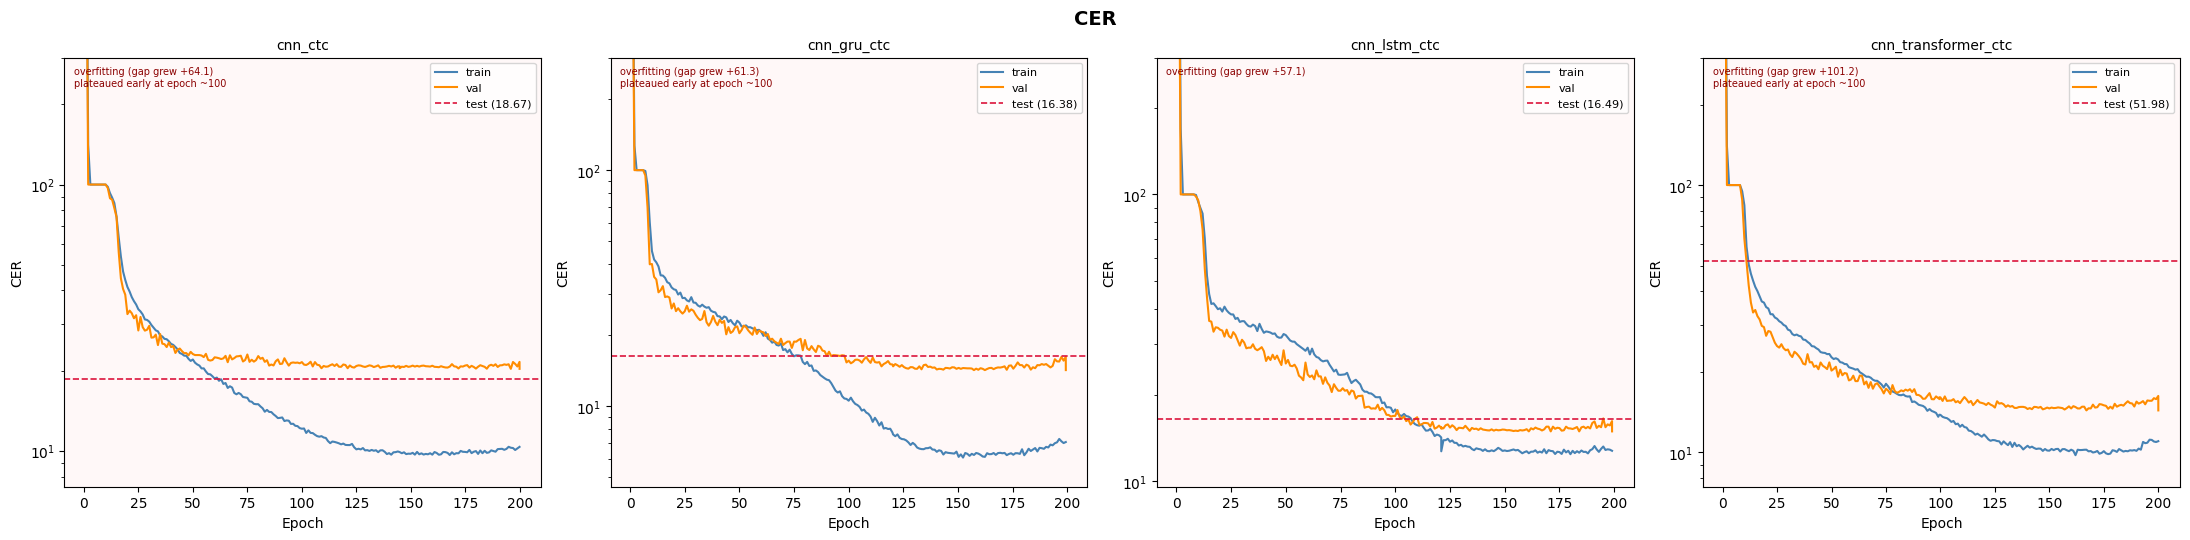

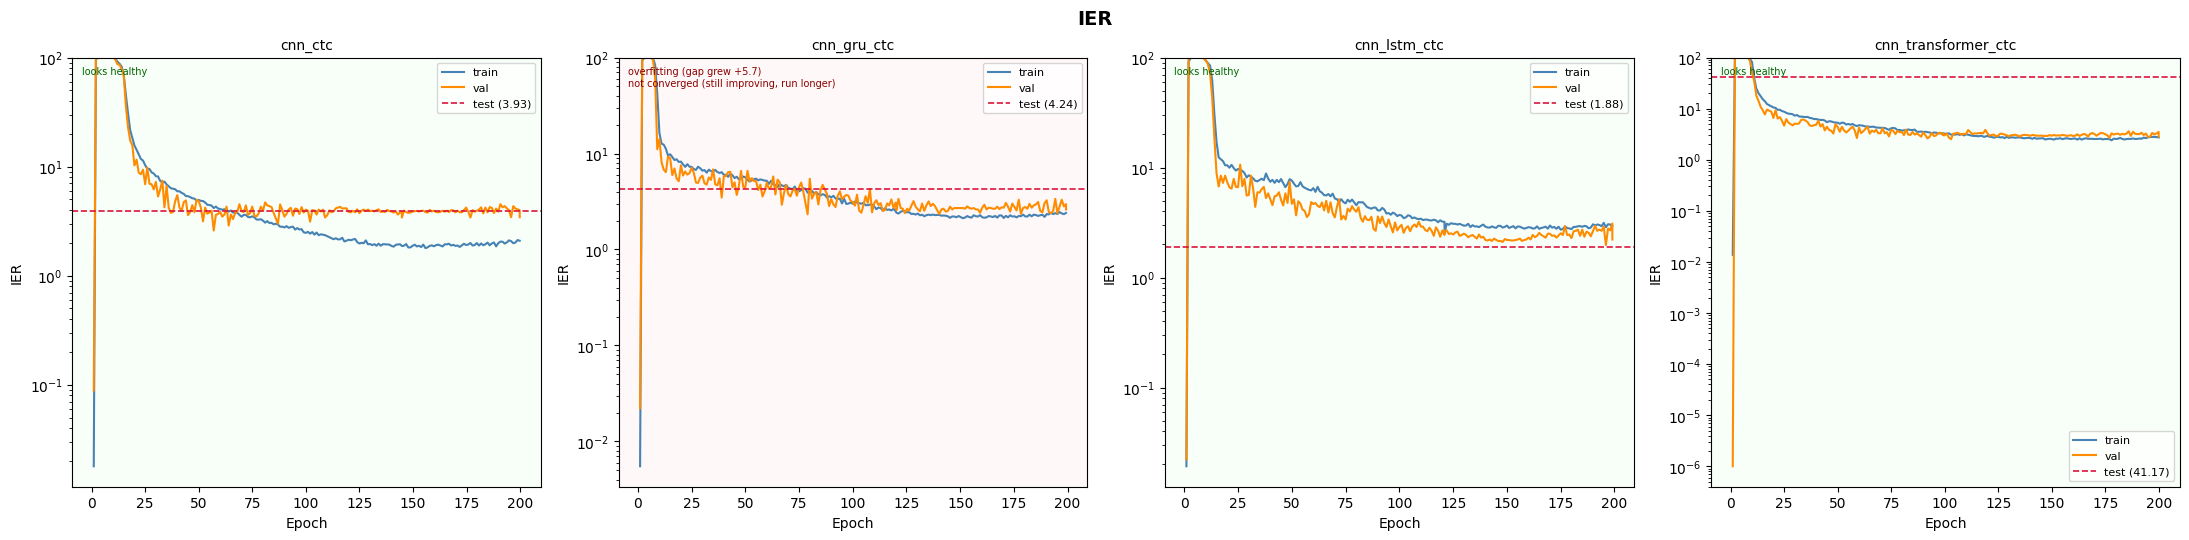

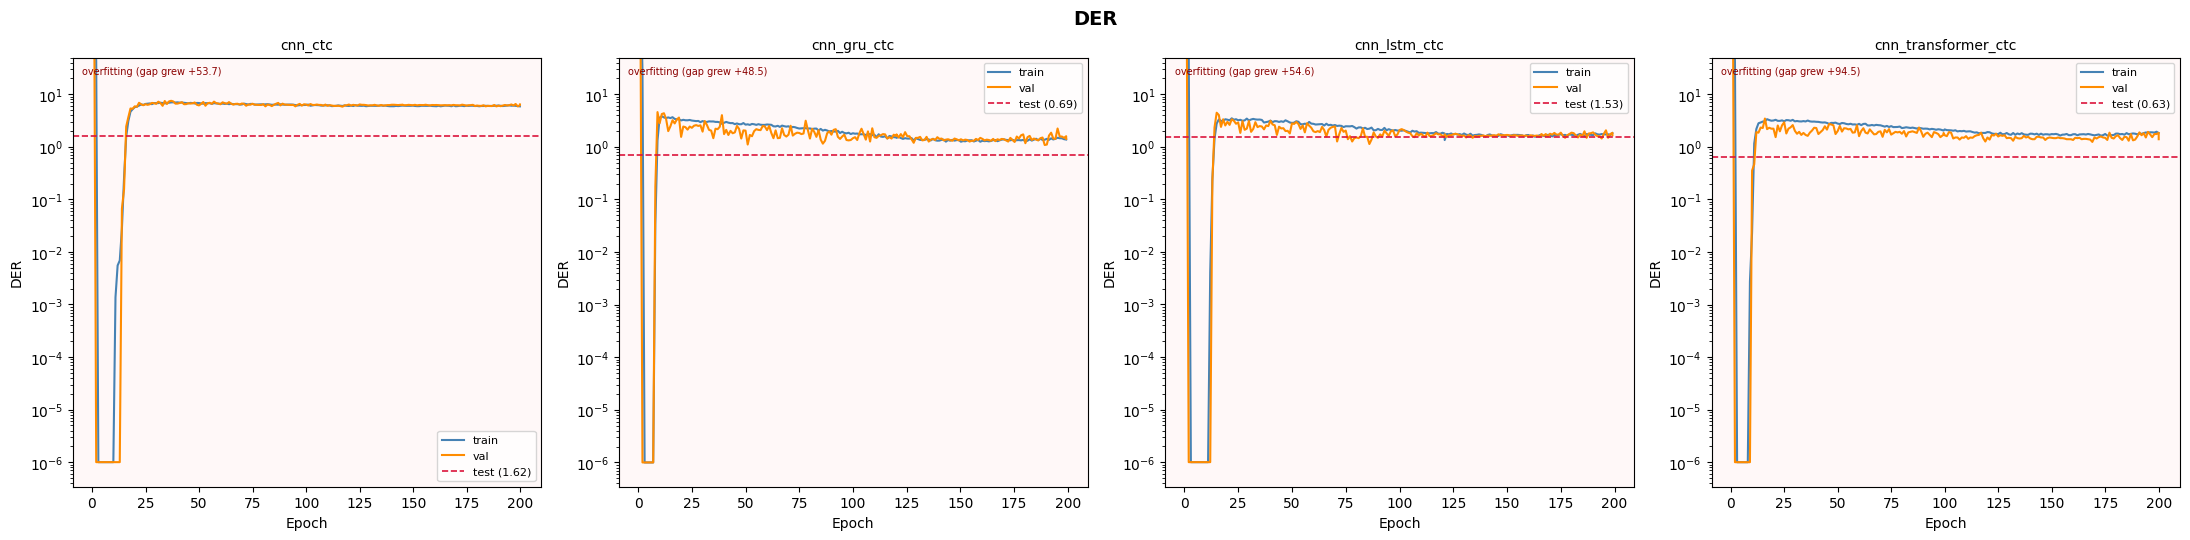

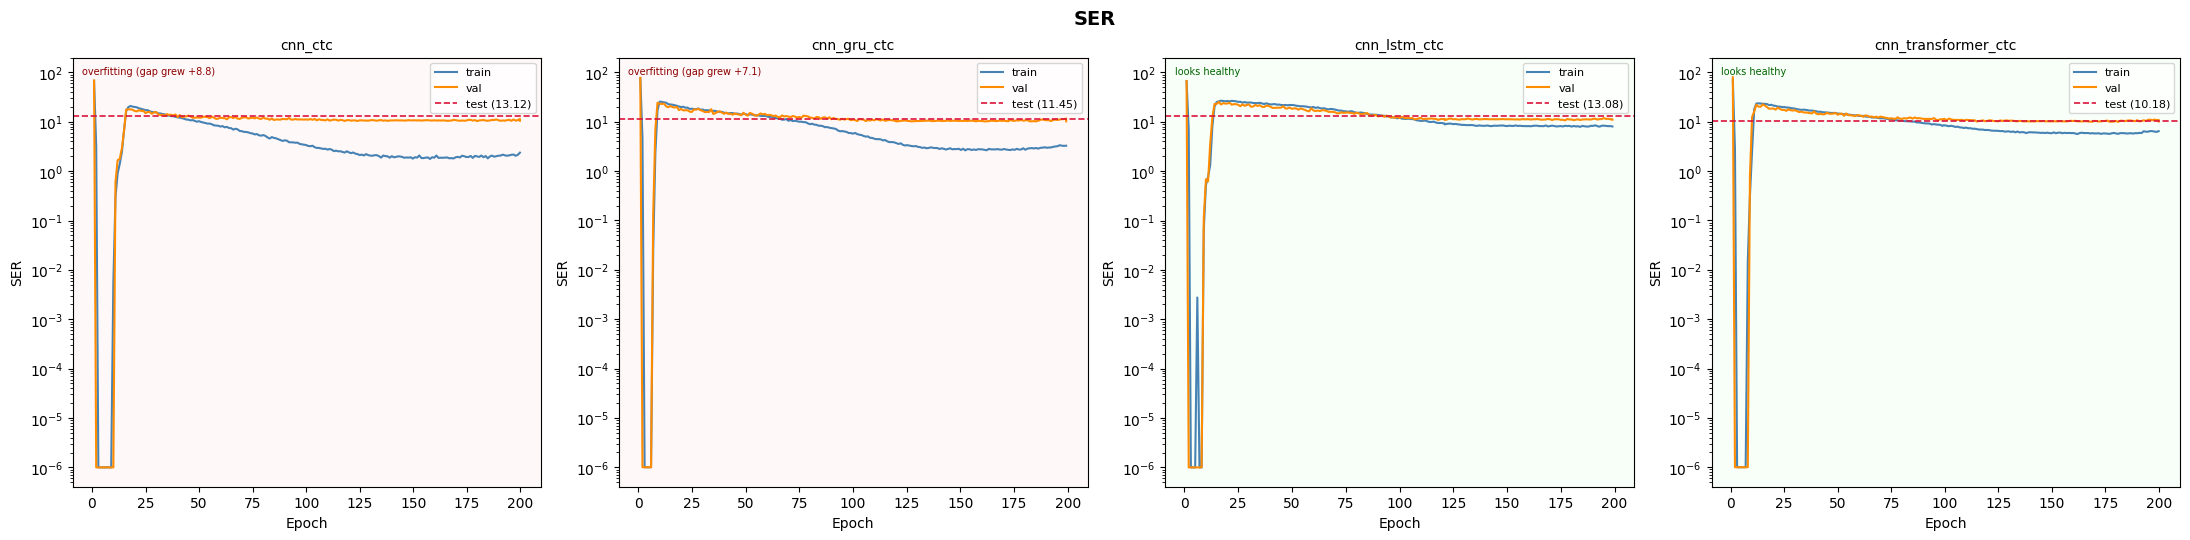

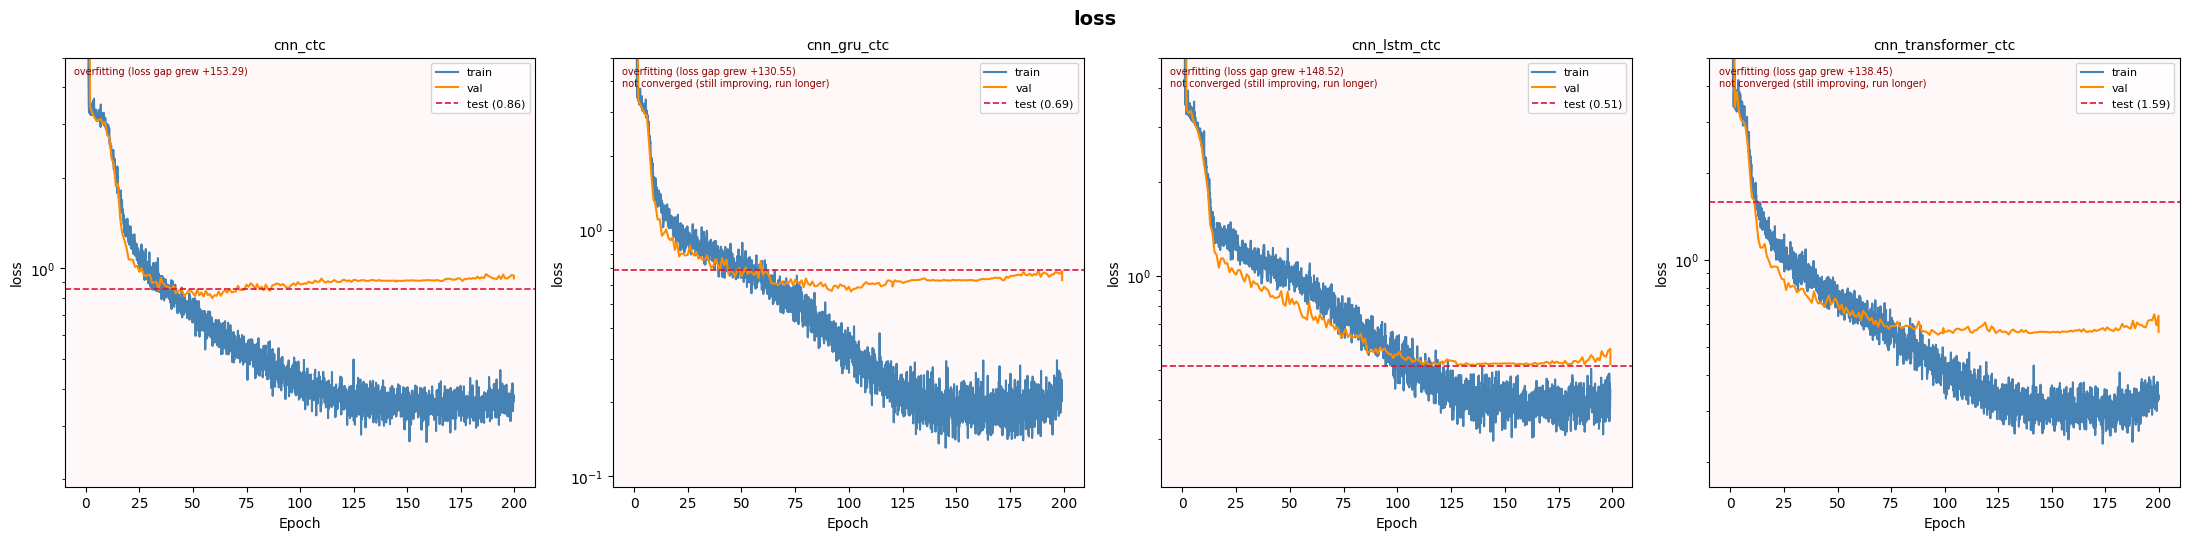

Saved 5 plots to /content/ECE_C147A_Final/Project/emg2qwerty/arch_sweep_plots.zip

Final Metrics Summary

cnn_ctc
  Metric          Train        Val       Test
  ----------------------------------------
  CER             10.34      20.31      18.67
  IER              2.09       3.43       3.93
  DER              5.88       6.40       1.62
  SER              2.37      10.48      13.12
  loss             0.38       0.93       0.86

cnn_gru_ctc
  Metric          Train        Val       Test
  ----------------------------------------
  CER              7.05      14.22      16.38
  IER              2.40       2.61       4.24
  DER              1.38       1.42       0.69
  SER              3.27      10.19      11.45
  loss             0.21       0.63       0.69

cnn_lstm_ctc
  Metric          Train        Val       Test
  ----------------------------------------
  CER             12.78      14.93      16.49
  IER              2.93       2.22       1.88
  DER              1.83       1.66      

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from google.colab import files
import zipfile
import io

configs = [
    "cnn_ctc",
    "cnn_gru_ctc",
    "cnn_lstm_ctc",
    "cnn_transformer_ctc",
]
base = Path("/content/ECE_C147A_Final/Project/emg2qwerty/logs")

def load_all_versions(log_dir: Path) -> dict:
    # collect every version_N dir, load all of them, merge by step
    versions = sorted(log_dir.glob("version_*"), key=lambda p: int(p.name.split("_")[1]))
    if not versions:
        raise FileNotFoundError(f"No version directories found in {log_dir}")

    merged: dict[str, list] = {}
    for v in versions:
        ea = EventAccumulator(str(v))
        ea.Reload()
        for tag in ea.Tags().get("scalars", []):
            entries = [{"step": e.step, "value": e.value} for e in ea.Scalars(tag)]
            merged.setdefault(tag, []).extend(entries)

    for tag in merged:
        seen = {}
        for entry in merged[tag]:
            seen[entry["step"]] = entry["value"]
        merged[tag] = [{"step": s, "value": v} for s, v in sorted(seen.items())]

    return merged

def steps_to_epochs(steps: np.ndarray, steps_per_epoch: float) -> np.ndarray:
    return steps / steps_per_epoch

def infer_steps_per_epoch(val_data: list) -> float:
    # val is logged once per epoch so median step delta = steps_per_epoch
    if len(val_data) < 2:
        return 1.0
    step_diffs = np.diff([d["step"] for d in val_data])
    return float(np.median(step_diffs))

def diagnose(train_vals, val_vals, metric):
    issues = []
    if len(train_vals) < 5 or len(val_vals) < 5:
        return ["insufficient data"]

    train   = np.array(train_vals)
    val     = np.array(val_vals)
    min_len = min(len(train), len(val))
    train   = train[:min_len]
    val     = val[:min_len]
    gap     = val - train

    if metric != "loss":
        late_gap  = gap[-10:].mean()
        early_gap = gap[:10].mean()
        if late_gap > early_gap + 5:
            issues.append(f"overfitting (gap grew +{late_gap - early_gap:.1f})")
    else:
        late_gap  = gap[-10:].mean()
        early_gap = gap[:10].mean()
        if late_gap > early_gap + 0.1:
            issues.append(f"overfitting (loss gap grew +{late_gap - early_gap:.2f})")

    if metric == "CER":
        if val[-1] > 40 and (val[-10] - val[-1]) > 1:
            issues.append(f"underfitting (val CER still {val[-1]:.1f}% and declining)")
        elif val[-1] > 40:
            issues.append(f"high CER plateau ({val[-1]:.1f}%) - may need architecture change")

    if (val[-10] - val[-1]) / (abs(val[-1]) + 1e-6) > 0.05:
        issues.append("not converged (still improving, run longer)")

    if len(val) > 20:
        mid_improvement = val[len(val)//2] - val[-1]
        if abs(mid_improvement) < 0.5 and metric == "CER":
            issues.append(f"plateaued early at epoch ~{len(val)//2}")

    return issues if issues else ["looks healthy"]

results = {}
for name in configs:
    all_scalars = load_all_versions(base / name / "lightning_logs")
    results[name] = {
        "train": {t.split("/")[1]: all_scalars[t] for t in all_scalars if t.startswith("train/")},
        "val":   {t.split("/")[1]: all_scalars[t] for t in all_scalars if t.startswith("val/")},
        "test":  {t.split("/")[1]: all_scalars[t] for t in all_scalars if t.startswith("test/")},
    }

with open("arch_sweep_results.json", "w") as f:
    json.dump(results, f, indent=2)

# ── plots ──────────────────────────────────────────────────────────────────────

Y_CLIP = {"CER": 300, "IER": 100, "DER": 50, "SER": 200, "loss": 5}
metrics = ["CER", "IER", "DER", "SER", "loss"]

zip_path = "/content/ECE_C147A_Final/Project/emg2qwerty/arch_sweep_plots.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for metric in metrics:
        fig, axes = plt.subplots(2, 4, figsize=(22, 10))
        fig.suptitle(metric, fontsize=14, fontweight="bold")
        axes_flat = axes.flatten()

        for col, name in enumerate(configs):
            ax = axes_flat[col]

            val_cer_data = results[name]["val"].get("CER", [])
            spe = infer_steps_per_epoch(val_cer_data) if val_cer_data else 1.0

            for phase, color in [("train", "steelblue"), ("val", "darkorange")]:
                data = results[name][phase].get(metric, [])
                if not data:
                    continue
                values = np.clip([d["value"] for d in data], 1e-6, None)
                epochs = steps_to_epochs(np.array([d["step"] for d in data]), spe)
                ax.plot(epochs, values, label=phase, color=color)

            test_data = results[name]["test"].get(metric, [])
            if test_data:
                test_val = max(test_data, key=lambda d: d["step"])["value"]
                test_val = max(test_val, 1e-6)
                ax.axhline(test_val, color="crimson", linestyle="--", linewidth=1.2,
                           label=f"test ({test_val:.2f})")

            ax.set_yscale("log")
            ax.set_ylim(top=Y_CLIP.get(metric))
            ax.set_title(name, fontsize=10)
            ax.set_xlabel("Epoch")
            ax.set_ylabel(metric)
            ax.legend(fontsize=8)

            train_vals = [d["value"] for d in results[name]["train"].get(metric, [])]
            val_vals   = [d["value"] for d in results[name]["val"].get(metric, [])]
            issues     = diagnose(train_vals, val_vals, metric)
            ax.set_facecolor("#fff8f8" if issues != ["looks healthy"] else "#f8fff8")
            ax.text(0.02, 0.98, "\n".join(issues), transform=ax.transAxes,
                    fontsize=7, va="top", color="darkred" if issues != ["looks healthy"] else "darkgreen")

        for ax in axes_flat[len(configs):]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()

        # save to zip in memory at high quality
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=200, bbox_inches="tight")
        buf.seek(0)
        zf.writestr(f"{metric}.png", buf.read())
        plt.close(fig)

print(f"Saved {len(metrics)} plots to {zip_path}")

# ── final metrics summary ──────────────────────────────────────────────────────

print("\nFinal Metrics Summary")
print("=" * 70)
for name in configs:
    print(f"\n{name}")
    print(f"  {'Metric':<10} {'Train':>10} {'Val':>10} {'Test':>10}")
    print(f"  {'-'*40}")
    for metric in metrics:
        train_val = results[name]["train"].get(metric, [])
        val_val   = results[name]["val"].get(metric, [])
        test_val  = results[name]["test"].get(metric, [])
        t  = f"{train_val[-1]['value']:.2f}" if train_val else "N/A"
        v  = f"{val_val[-1]['value']:.2f}"   if val_val   else "N/A"
        te = f"{test_val[-1]['value']:.2f}"  if test_val  else "N/A"
        print(f"  {metric:<10} {t:>10} {v:>10} {te:>10}")

# ── full run csv ───────────────────────────────────────────────────────────────

all_rows = []
for name in configs:
    val_cer_data = results[name]["val"].get("CER", [])
    spe = infer_steps_per_epoch(val_cer_data) if val_cer_data else 1.0

    for phase in ["train", "val", "test"]:
        for metric in metrics:
            for entry in results[name][phase].get(metric, []):
                all_rows.append({
                    "model":  name,
                    "phase":  phase,
                    "metric": metric,
                    "step":   entry["step"],
                    "epoch":  round(entry["step"] / spe, 2),
                    "value":  entry["value"],
                })

csv_path = "/content/ECE_C147A_Final/Project/emg2qwerty/arch_sweep_full.csv"
with open(csv_path, "w") as f:
    f.write("model,phase,metric,step,epoch,value\n")
    for row in all_rows:
        f.write(f"{row['model']},{row['phase']},{row['metric']},{row['step']},{row['epoch']},{row['value']}\n")

print(f"Saved {len(all_rows)} rows to {csv_path}")

files.download(zip_path)
files.download(csv_path)

In [ ]:
import subprocess, sys

result = subprocess.run([
    sys.executable, "-m", "emg2qwerty.train",
    "train=False",
    f"checkpoint='{CHECKPOINT}'",
    f"model={MODEL_NAME}",
    "decoder=ctc_beam",
    "decoder.beam_size=5",
    "decoder.lm_path=null",
], capture_output=True, text=True, cwd="/content/ECE_C147A_Final/Project/emg2qwerty")

print(result.stdout[-2000:])
print(result.stderr[-2000:])

 ?it/s]
Validation DataLoader 0: 100%|██████████| 7/7 [00:49<00:00,  7.13s/it]
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃  Runningstage.validating  ┃                           ┃
┃          metric           ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val/CER          │           100.0           │
│          val/DER          │            0.0            │
│          val/IER          │           100.0           │
│          val/SER          │            0.0            │
│         val/loss          │    16.371416091918945     │
└───────────────────────────┴───────────────────────────┘

Testing: 0it [00:00, ?it/s]
Testing DataLoader 0: 100%|██████████| 1/1 [00:58<00:00, 58.56s/it]
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   Runningstage.testing    ┃                           ┃
┃          metric           ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         te

In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
import itertools
import re
import subprocess
import sys
import json
import time
import glob
import pandas as pd
from pathlib import Path

DATA_ROOT  = "/content/ECE_C147A_Final/Project/emg2qwerty/data"
MODEL_NAME = "cnn_lstm_ctc"

ckpt_files = glob.glob(f"/content/ECE_C147A_Final/Project/emg2qwerty/logs/{MODEL_NAME}/checkpoints/*.ckpt")
CHECKPOINT = next(f for f in ckpt_files if "last" not in f)
print(f"Using checkpoint: {Path(CHECKPOINT).name}")

def extract(combined, key):
    m = re.search(rf"'{re.escape(key)}':\s*([\d.]+)", combined)
    return float(m.group(1)) if m else None

def run_eval(lm_weight, insertion_bonus, beam_size):
    result = subprocess.run([
        sys.executable, "-m", "emg2qwerty.train",
        "user=single_user",
        "train=false",
        f"checkpoint='{CHECKPOINT}'",
        f"model={MODEL_NAME}",
        "transforms=fourier_features",
        f"dataset.root={DATA_ROOT}",
        "trainer.accelerator=gpu",
        "trainer.devices=1",
        "+trainer.limit_val_batches=0",
        "decoder=ctc_beam",
        f"decoder.beam_size={beam_size}",
        f"decoder.lm_weight={lm_weight}",
        f"decoder.insertion_bonus={insertion_bonus}",
        f"hydra.run.dir=/content/ECE_C147A_Final/Project/emg2qwerty/logs/{MODEL_NAME}_lm_sweep_tmp",
    ], capture_output=True, text=True, cwd="/content/ECE_C147A_Final/Project/emg2qwerty")
    combined = result.stdout + result.stderr
    return extract(combined, "test/CER"), combined

# ── coarse sweep at beam5 ──────────────────────────────────────────────────────

LM_WEIGHTS_COARSE      = [1.5, 2.0, 2.5, 3.0]
INSERTION_BONUS_COARSE = [1.5, 2.0, 2.5, 3.0]

combos = list(itertools.product(LM_WEIGHTS_COARSE, INSERTION_BONUS_COARSE))
print(f"\nCoarse sweep: {len(combos)} combos at beam5")

coarse_rows = []
sweep_start = time.time()

for i, (lm_weight, insertion_bonus) in enumerate(combos):
    run_start = time.time()
    elapsed   = run_start - sweep_start
    avg_time  = elapsed / i if i > 0 else 0
    eta       = avg_time * (len(combos) - i)

    print(f"\n[{i+1}/{len(combos)}]  lm_weight={lm_weight}  insertion_bonus={insertion_bonus}")
    if i > 0:
        print(f"  elapsed={elapsed/60:.1f}min  eta={eta/60:.1f}min  avg/run={avg_time:.0f}s")

    test_cer, combined = run_eval(lm_weight, insertion_bonus, beam_size=5)
    run_time = time.time() - run_start

    if test_cer is None:
        print(f"  FAILED ({run_time:.0f}s)")
        print(combined[-1000:])
        continue

    print(f"  test CER={test_cer:.2f}  ({run_time:.0f}s)")
    coarse_rows.append({"lm_weight": lm_weight, "insertion_bonus": insertion_bonus, "test_CER": test_cer})
    best = min(coarse_rows, key=lambda x: x["test_CER"])
    print(f"  best so far: lm_weight={best['lm_weight']}  insertion_bonus={best['insertion_bonus']}  test CER={best['test_CER']:.2f}")

df_coarse = pd.DataFrame(coarse_rows).sort_values("test_CER")
print(f"\nCoarse sweep done in {(time.time() - sweep_start)/60:.1f}min")

# ── confirm top 3 at beam25 ────────────────────────────────────────────────────

top5 = df_coarse.head(3)
print(f"\nConfirming top 5 combos at beam25:")

confirm_rows = []
for _, row in top3.iterrows():
    lm_weight, insertion_bonus = row["lm_weight"], row["insertion_bonus"]
    print(f"\n  lm_weight={lm_weight}  insertion_bonus={insertion_bonus}")
    test_cer, combined = run_eval(lm_weight, insertion_bonus, beam_size=25)
    if test_cer is None:
        print(f"  FAILED")
        print(combined[-1000:])
        continue
    print(f"  beam5={row['test_CER']:.2f}  beam25={test_cer:.2f}")
    confirm_rows.append({"lm_weight": lm_weight, "insertion_bonus": insertion_bonus,
                         "beam5_CER": row["test_CER"], "beam25_CER": test_cer})

# ── final summary ──────────────────────────────────────────────────────────────

print("\nFinal Metrics Summary")
print("=" * 70)
print(f"\n{MODEL_NAME} — coarse grid (beam5)")
print(f"  {'lm_weight':<14} {'insert_bonus':<14} {'Test CER':>10}")
print(f"  {'-'*42}")
for _, row in df_coarse.iterrows():
    print(f"  {row['lm_weight']:<14} {row['insertion_bonus']:<14} {row['test_CER']:>10.2f}")

if confirm_rows:
    df_confirm = pd.DataFrame(confirm_rows).sort_values("beam25_CER")
    print(f"\n{MODEL_NAME} — top 3 confirmed (beam25)")
    print(f"  {'lm_weight':<14} {'insert_bonus':<14} {'beam5 CER':>10} {'beam25 CER':>10}")
    print(f"  {'-'*52}")
    for _, row in df_confirm.iterrows():
        print(f"  {row['lm_weight']:<14} {row['insertion_bonus']:<14} {row['beam5_CER']:>10.2f} {row['beam25_CER']:>10.2f}")

    best = df_confirm.iloc[0]
    print(f"\nBest: lm_weight={best['lm_weight']}  insertion_bonus={best['insertion_bonus']}  beam25 CER={best['beam25_CER']:.2f}")

with open(f"lm_sweep_{MODEL_NAME}.json", "w") as f:
    json.dump({"coarse": coarse_rows, "confirmed": confirm_rows}, f, indent=2)

/content/ECE_C147A_Final/Project/emg2qwerty
Using checkpoint: epoch=161-step=9661.ckpt

Coarse sweep: 16 combos at beam5

[1/16]  lm_weight=1.5  insertion_bonus=1.5
  test CER=9.96  (122s)
  best so far: lm_weight=1.5  insertion_bonus=1.5  test CER=9.96

[2/16]  lm_weight=1.5  insertion_bonus=2.0
  elapsed=2.0min  eta=30.6min  avg/run=122s
  test CER=10.24  (121s)
  best so far: lm_weight=1.5  insertion_bonus=1.5  test CER=9.96

[3/16]  lm_weight=1.5  insertion_bonus=2.5
  elapsed=4.1min  eta=28.4min  avg/run=122s
  test CER=10.05  (124s)
  best so far: lm_weight=1.5  insertion_bonus=1.5  test CER=9.96

[4/16]  lm_weight=1.5  insertion_bonus=3.0
  elapsed=6.1min  eta=26.5min  avg/run=123s
  test CER=10.24  (121s)
  best so far: lm_weight=1.5  insertion_bonus=1.5  test CER=9.96

[5/16]  lm_weight=2.0  insertion_bonus=1.5
  elapsed=8.1min  eta=24.4min  avg/run=122s
  test CER=9.60  (124s)
  best so far: lm_weight=2.0  insertion_bonus=1.5  test CER=9.60

[6/16]  lm_weight=2.0  insertion_b

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
from pathlib import Path

configs = [
    {"name": "cnn_ctc",             "model": "cnn_ctc"},
    {"name": "cnn_gru_ctc",         "model": "cnn_gru_ctc"},
    {"name": "cnn_lstm_ctc",        "model": "cnn_lstm_ctc"},
    {"name": "cnn_transformer_ctc", "model": "cnn_transformer_ctc"},
]

DATA_ROOT = "/content/ECE_C147A_Final/Project/emg2qwerty/data"

def find_best_checkpoint(name: str) -> str:
    ckpt_dir = Path(f"/content/ECE_C147A_Final/Project/emg2qwerty/logs/{name}/checkpoints")
    candidates = [p for p in ckpt_dir.glob("*.ckpt") if not p.name.startswith("last")]
    if not candidates:
        raise FileNotFoundError(f"No best checkpoint found in {ckpt_dir}")
    return str(max(candidates, key=lambda p: int(p.stem.split("step=")[1])))

decoders = [
    {"tag": "greedy", "decoder": "ctc_greedy", "extra": ""},
    {"tag": "beam20", "decoder": "ctc_beam",   "extra": "decoder.beam_size=25"},
]

for cfg in configs:
    best_ckpt = find_best_checkpoint(cfg["name"])
    print(f"\n{'='*60}\n{cfg['name']}  |  checkpoint: {Path(best_ckpt).name}\n{'='*60}")

    for dec in decoders:
        out_dir = f"/content/ECE_C147A_Final/Project/emg2qwerty/logs/{cfg['name']}_{dec['tag']}"
        print(f"\n-- decoder: {dec['tag']} --")
        !python -m emg2qwerty.train \
            user=single_user \
            model={cfg['model']} \
            transforms=fourier_features \
            "dataset.root={DATA_ROOT}" \
            train=false \
            trainer.accelerator=gpu \
            trainer.devices=1 \
            decoder={dec['decoder']} \
            {dec['extra']} \
            "checkpoint='{best_ckpt}'" \
            "hydra.run.dir={out_dir}"

/content/ECE_C147A_Final/Project/emg2qwerty

cnn_ctc  |  checkpoint: epoch=195-step=11750.ckpt

-- decoder: greedy --
[2026-03-10 04:42:28,244][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b

In [ ]:
%cd /content/ECE_C147A_Final/Project/emg2qwerty
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

decoders = ["greedy", "beam25"]
metrics  = ["CER", "IER", "DER", "SER", "loss"]

def load_eval_metrics(log_dir: Path) -> dict:
    # eval runs produce a single version_0; read all scalars from it
    versions = sorted(log_dir.glob("lightning_logs/version_*"),
                      key=lambda p: int(p.name.split("_")[1]))
    if not versions:
        return {}
    ea = EventAccumulator(str(versions[-1]))
    ea.Reload()
    result = {}
    for tag in ea.Tags().get("scalars", []):
        entries = ea.Scalars(tag)
        if entries:
            # take the last logged value
            result[tag] = entries[-1].value
    return result

# collect results[model][decoder][phase][metric]
results = {}
for cfg in configs:
    results[cfg["name"]] = {}
    for dec_tag in decoders:
        log_dir = Path(f"logs/{cfg['name']}_{dec_tag}")
        scalars = load_eval_metrics(log_dir)
        results[cfg["name"]][dec_tag] = {
            "val":  {t.split("/")[1]: v for t, v in scalars.items() if t.startswith("val/")},
            "test": {t.split("/")[1]: v for t, v in scalars.items() if t.startswith("test/")},
        }

print("\nFinal Metrics Summary")
print("=" * 70)
for cfg in configs:
    print(f"\n{cfg['name']}")
    for dec_tag in decoders:
        print(f"\n  [{dec_tag}]")
        print(f"  {'Metric':<10} {'Val':>10} {'Test':>10}")
        print(f"  {'-'*30}")
        for metric in metrics:
            v  = results[cfg["name"]][dec_tag]["val"].get(metric)
            te = results[cfg["name"]][dec_tag]["test"].get(metric)
            v_str  = f"{v:.2f}"  if v  is not None else "N/A"
            te_str = f"{te:.2f}" if te is not None else "N/A"
            print(f"  {metric:<10} {v_str:>10} {te_str:>10}")

/content/ECE_C147A_Final/Project/emg2qwerty

Final Metrics Summary

cnn_ctc

  [greedy]
  Metric            Val       Test
  ------------------------------
  CER             20.34      18.67
  IER              3.43       3.93
  DER              6.42       1.62
  SER             10.48      13.12
  loss             0.93       0.86

  [beam20]
  Metric            Val       Test
  ------------------------------
  CER             16.42      13.51
  IER              4.98       6.55
  DER              5.38       0.78
  SER              6.05       6.18
  loss             0.93       0.86

cnn_gru_ctc

  [greedy]
  Metric            Val       Test
  ------------------------------
  CER             14.22      16.38
  IER              2.61       4.24
  DER              1.42       0.69
  SER             10.19      11.45
  loss             0.63       0.69

  [beam20]
  Metric            Val       Test
  ------------------------------
  CER             11.12      11.39
  IER              2.66       4